In [ ]:
#  1. นำเข้าไลบรารีที่จำเป็น
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# แสดงกราฟให้คมชัด
plt.style.use("ggplot")
sns.set(font_scale=1.1)


In [ ]:
#  2. โหลดชุดข้อมูล
df = pd.read_csv("Customer-Churn-Records.csv")

In [ ]:
#  3. ดูข้อมูลเบื้องต้น
print(" ขนาดของข้อมูล:", df.shape)
print("\n ข้อมูล 5 แถวแรก:")
print(df.head())

print("\n ชนิดข้อมูล:")
print(df.info())

 ขนาดของข้อมูล: (10000, 18)

 ข้อมูล 5 แถวแรก:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1     

In [ ]:
#  4. ตรวจสอบค่าสถิติพื้นฐาน
print("\n ค่าสถิติพื้นฐาน:")
print(df.describe())


 ค่าสถิติพื้นฐาน:
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min   

In [ ]:
#  5. ตรวจสอบค่าหาย
print("\n ตรวจสอบค่าหาย:")
print(df.isnull().sum())


 ตรวจสอบค่าหาย:
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [ ]:
#  6. สัดส่วนลูกค้าที่เลิกใช้บริการ
churn_rate = df["Exited"].value_counts(normalize=True) * 100
print("\n อัตราการเลิกใช้บริการ:")
print(churn_rate)


 อัตราการเลิกใช้บริการ:
Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


/tmp/ipython-input-1659997493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Exited", data=df, palette="coolwarm")


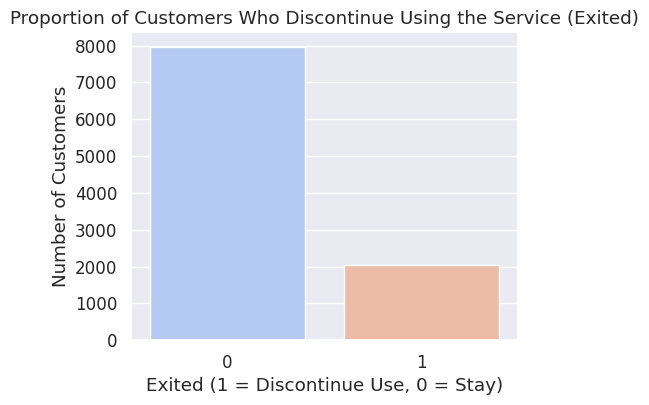

In [ ]:
#  7. กราฟสัดส่วนลูกค้าที่เลิกใช้
plt.figure(figsize=(5,4))
sns.countplot(x="Exited", data=df, palette="coolwarm")
plt.title("Proportion of Customers Who Discontinue Using the Service (Exited)")
plt.xlabel("Exited (1 = Discontinue Use, 0 = Stay)")
plt.ylabel("Number of Customers")
plt.show()

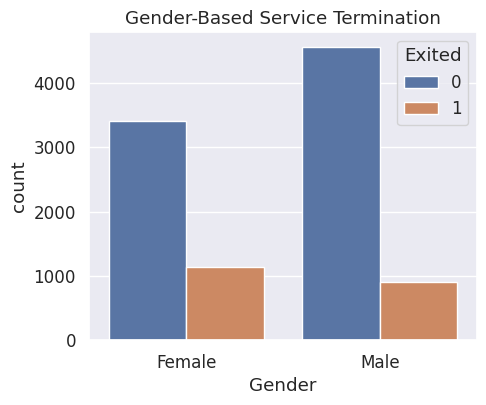

In [ ]:
#  8. การกระจายของเพศ
plt.figure(figsize=(5,4))
sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Gender-Based Service Termination")
plt.show()

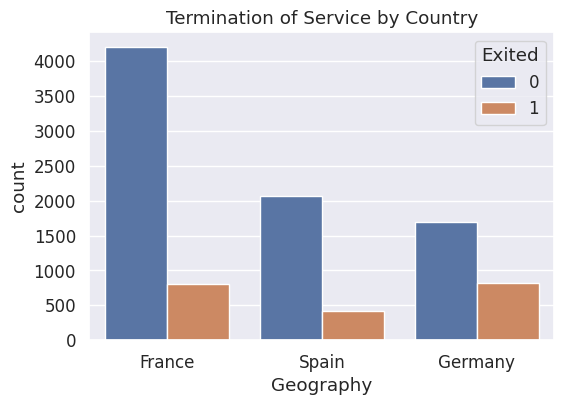

In [ ]:
#  9. การเลิกใช้บริการแยกตามประเทศ
plt.figure(figsize=(6,4))
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Termination of Service by Country")
plt.show()

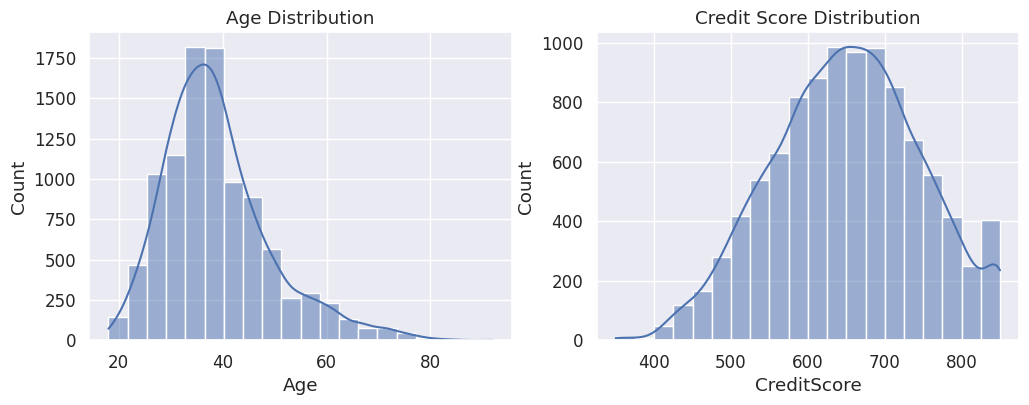

In [ ]:
#  10. Histogram อายุและคะแนนเครดิต
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df["CreditScore"], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Credit Score Distribution")
plt.show()





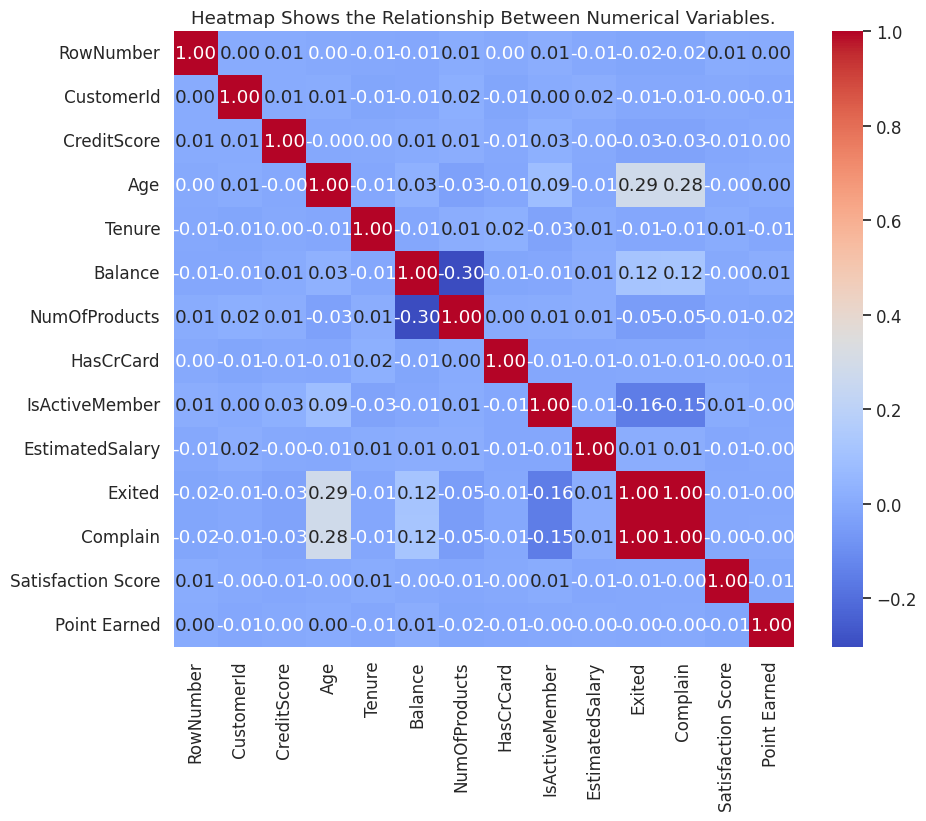

In [ ]:
#  11. ความสัมพันธ์ระหว่างตัวเลข
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Heatmap Shows the Relationship Between Numerical Variables.")
plt.show()

In [ ]:
#  12. Insight สั้น ๆ
print("\n Insight เบื้องต้น:")
print("- ลูกค้าประมาณ 20% เลิกใช้บริการ")
print("- ลูกค้าที่อายุน้อยหรือมีคะแนนเครดิตต่ำมักเลิกใช้มากกว่า")
print("- ความพึงพอใจและการร้องเรียนอาจมีผลต่อการเลิกใช้")
print("- ลูกค้าที่เป็น Active Member มักยังคงอยู่ต่อ")


 Insight เบื้องต้น:
- ลูกค้าประมาณ 20% เลิกใช้บริการ
- ลูกค้าที่อายุน้อยหรือมีคะแนนเครดิตต่ำมักเลิกใช้มากกว่า
- ความพึงพอใจและการร้องเรียนอาจมีผลต่อการเลิกใช้
- ลูกค้าที่เป็น Active Member มักยังคงอยู่ต่อ


In [ ]:
#  1. นำเข้าไลบรารีที่จำเป็น
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# โหลดข้อมูลอีกครั้ง (หากยังไม่ได้โหลด)
df = pd.read_csv("Customer-Churn-Records.csv")

#  2. ลบคอลัมน์ที่ไม่จำเป็น (ไม่มีผลต่อโมเดล)
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

#  3. เข้ารหัสข้อมูลแบบ Categorical เป็นตัวเลข
# Label Encoding สำหรับคอลัมน์ที่เป็นข้อความ
le = LabelEncoder()
df["Geography"] = le.fit_transform(df["Geography"])
df["Gender"] = le.fit_transform(df["Gender"])
df["Card Type"] = le.fit_transform(df["Card Type"])

# ตรวจสอบผลการแปลง
print("\n ข้อมูลหลังเข้ารหัส:")
print(df.head())

#  4. แยก Features (X) และ Target (y)
X = df.drop(columns=["Exited"])  # ตัวแปรอิสระ
y = df["Exited"]                # ตัวแปรเป้าหมาย

#  5. แบ่งข้อมูล Train/Test (80% : 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n ขนาดของชุดข้อมูล:")
print("Train set:", X_train.shape)
print("Test set:", X_test.shape)

#  6. ทำการ Standardize (ปรับสเกลข้อมูลตัวเลข)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n ข้อมูลหลังการปรับสเกลเรียบร้อย!")

# (ถ้าต้องการดูตัวอย่าง)
print("\nตัวอย่างข้อมูลหลัง Scaling (5 แถวแรก):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())



🔤 ข้อมูลหลังเข้ารหัส:
   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  Complain  \
0          1               1        101348.88       1         1   
1          0               1        112542.58       0         1   
2          1               0        113931.57       1         1   
3          0               0         93826.63       0         0   
4          1               1         79084.10       0         0   

   Satisfaction Score  Card Type  Point Earned  
0                   2          0           464  
1                  

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:16:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Model Evaluation Results:

===== Logistic Regression =====
Accuracy: 0.9985
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

--------------------------------------------------
===== Random Forest =====
Accuracy: 0.9985
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

--------------------------------------------------
===== XGBoost =====
Accuracy: 0.9985
              precision    recall  f1-score   support

           0       1.00      1.0

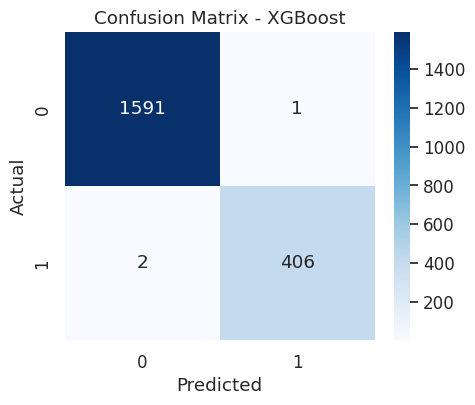

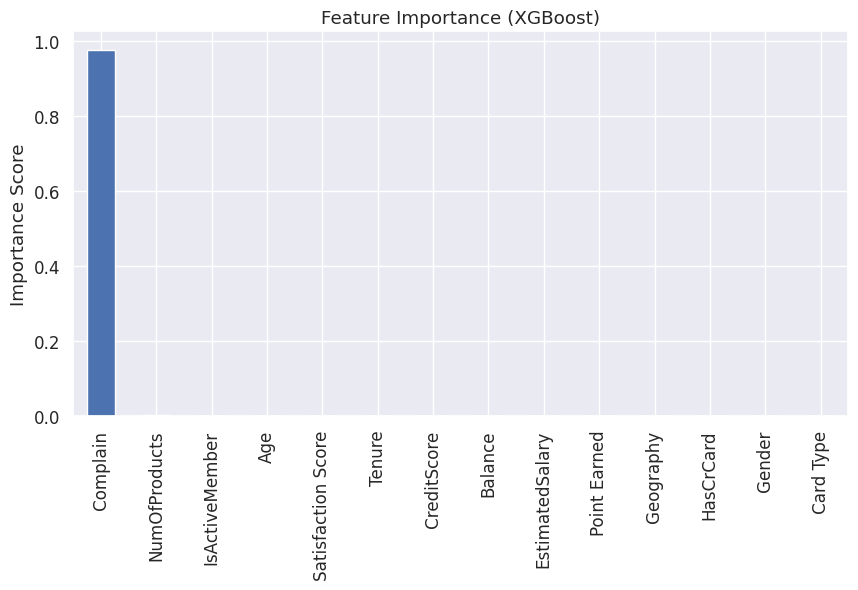

In [ ]:
#  สร้างโมเดล Machine Learning สำหรับทำนายการเลิกใช้บริการของลูกค้า

#  1. นำเข้าไลบรารี
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#  2. โหลดและเตรียมข้อมูล
df = pd.read_csv("Customer-Churn-Records.csv")

# ลบคอลัมน์ที่ไม่จำเป็น
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# เข้ารหัสข้อมูลตัวอักษร
le = LabelEncoder()
df["Geography"] = le.fit_transform(df["Geography"])
df["Gender"] = le.fit_transform(df["Gender"])
df["Card Type"] = le.fit_transform(df["Card Type"])

# แยก Feature และ Target
X = df.drop(columns=["Exited"])
y = df["Exited"]

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ปรับสเกลข้อมูล
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  3. สร้างและเทรนโมเดล

# Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

#  4. ประเมินผลลัพธ์

print(" Model Evaluation Results:\n")

models = {
    "Logistic Regression": (y_test, y_pred_log),
    "Random Forest": (y_test, y_pred_rf),
    "XGBoost": (y_test, y_pred_xgb)
}

for name, (y_true, y_pred) in models.items():
    print(f"===== {name} =====")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print(classification_report(y_true, y_pred))
    print("-" * 50)

#  5. แสดง Confusion Matrix ของโมเดลที่ดีที่สุด (XGBoost)
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  6. แสดงความสำคัญของ Feature (Feature Importance)
feature_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance (XGBoost)")
plt.ylabel("Importance Score")
plt.show()
